# LeNet-5

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


**Why Resize instead of the original padding.** The original LeNet-5 input
was constructed by padding the 28×28 MNIST digit with a 2-pixel zero border
to reach 32×32, keeping the digit's native scale unchanged. We used
`transforms.Resize((32, 32))` instead, which interpolates the image up to
32×32. This is simpler to implement and close enough in spirit for our
purposes, but it slightly stretches the digit rather than preserving its
original pixel scale - worth keeping in mind if results are compared against
the original paper's reported figures.

In [3]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # mean/std for MNIST
])

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

100.0%
100.0%
100.0%
100.0%

Train size: 60000, Test size: 10000
Image shape: torch.Size([1, 32, 32])


In [4]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")   # [128, 1, 32, 32]
print(f"Batch labels shape: {labels.shape}")   # [128]

Batch images shape: torch.Size([128, 1, 32, 32])
Batch labels shape: torch.Size([128])


In [6]:
class RBFOutput(nn.Module):
    def __init__(self, num_classes=10, in_features=84):
        super().__init__()
        prototypes = torch.randint(0, 2, (num_classes, in_features)).float() * 2 - 1
        self.register_buffer("prototypes", prototypes)

    def forward(self, x):
        # x: [batch, in_features], prototypes: [num_classes, in_features]
        x = x.unsqueeze(1)                          # [batch, 1, in_features]
        protos = self.prototypes.unsqueeze(0)        # [1, num_classes, in_features]
        dist2 = ((x - protos) ** 2).sum(dim=2)        # [batch, num_classes]
        return dist2


class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.c1 = nn.Conv2d(1, 6, kernel_size=5)
        self.s2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.c3 = nn.Conv2d(6, 16, kernel_size=5)
        self.s4 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.c5 = nn.Conv2d(16, 120, kernel_size=5)
        self.f6 = nn.Linear(120, 84)
        self.rbf = RBFOutput(num_classes=num_classes, in_features=84)
        self.act = nn.Tanh()

    def forward(self, x):
        x = self.act(self.c1(x))
        x = self.s2(x)
        x = self.act(self.c3(x))
        x = self.s4(x)
        x = self.act(self.c5(x))
        x = x.flatten(1)
        x = self.act(self.f6(x))
        x = self.rbf(x)
        return x

model = LeNet5().to(device)
print(model)

LeNet5(
  (c1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (s2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (c3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (s4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (c5): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (f6): Linear(in_features=120, out_features=84, bias=True)
  (rbf): RBFOutput()
  (act): Tanh()
)


In [7]:
class MAPLoss(nn.Module):
    def __init__(self, j=1.0):
        super().__init__()
        self.j = j

    def forward(self, dist2, targets):
        batch_size = dist2.size(0)

        correct_dist = dist2[torch.arange(batch_size), targets]

        neg_j_term = torch.full((batch_size,), -self.j, device=dist2.device)
        log_sum_exp_input = torch.cat(
            [neg_j_term.unsqueeze(1), -dist2], dim=1
        )
        penalty = torch.logsumexp(log_sum_exp_input, dim=1)

        loss = correct_dist + penalty
        return loss.mean()


criterion = MAPLoss(j=1.0)

model.eval()
with torch.no_grad():
    sample_images, sample_labels = images.to(device), labels.to(device)
    sample_out = model(sample_images)
    sample_loss = criterion(sample_out, sample_labels)
    print(f"Sample MAP loss: {sample_loss.item():.4f}")

Sample MAP loss: 84.8184


**Why Adam instead of SGD.** The original 1998 paper used plain SGD with a
manually scheduled learning rate. We used Adam here for practical
convenience — it converges reliably without hand-tuning a schedule, which
matters given we only train for a single epoch. This is a deliberate
deviation from the original optimizer choice; the architecture itself
(including the RBF output layer and MAP loss) was kept faithful to the paper.

In [14]:
LEARNING_RATE = 1e-3
NUM_EPOCHS = 5

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        dist2 = model(images)
        loss = criterion(dist2, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = dist2.argmin(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        dist2 = model(images)
        loss = criterion(dist2, labels)

        total_loss += loss.item() * images.size(0)
        preds = dist2.argmin(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [15]:
import time

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/5 | train_loss=1.3732 train_acc=0.9942 | val_loss=1.8350 val_acc=0.9903 | time=4.8s
Epoch 2/5 | train_loss=1.2436 train_acc=0.9951 | val_loss=1.8773 val_acc=0.9898 | time=4.5s
Epoch 3/5 | train_loss=1.1732 train_acc=0.9953 | val_loss=1.8618 val_acc=0.9898 | time=4.4s
Epoch 4/5 | train_loss=1.1041 train_acc=0.9960 | val_loss=1.7030 val_acc=0.9902 | time=4.4s
Epoch 5/5 | train_loss=1.0597 train_acc=0.9962 | val_loss=1.7372 val_acc=0.9908 | time=4.4s


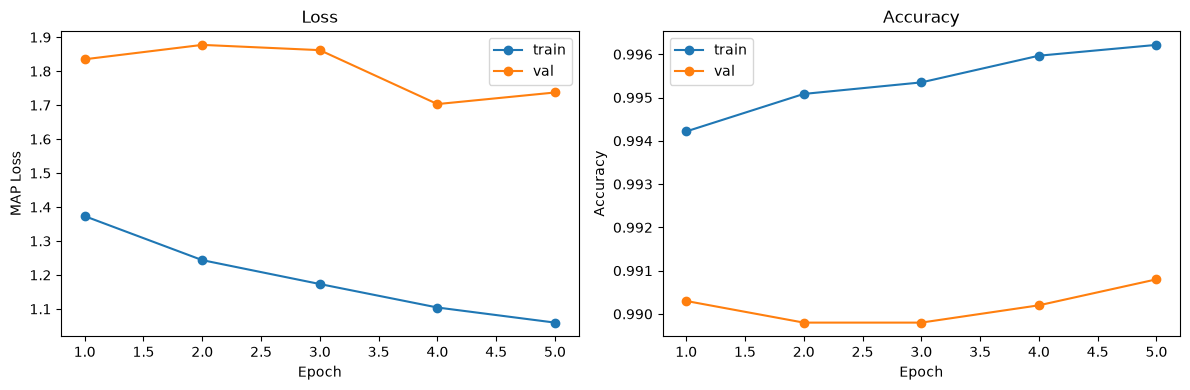

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAP Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

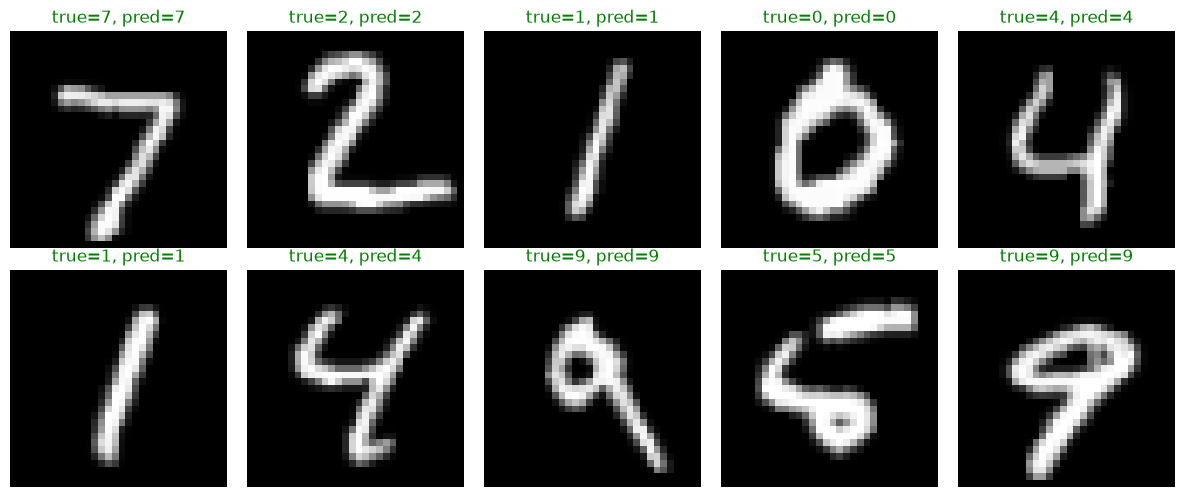

In [17]:
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images_device = sample_images.to(device)

with torch.no_grad():
    dist2 = model(sample_images_device)
    preds = dist2.argmin(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].squeeze().numpy()
    ax.imshow(img, cmap="gray")
    true_label = sample_labels[i].item()
    pred_label = preds[i].item()
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"true={true_label}, pred={pred_label}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** The convolutional layers (C1, C3, C5) contain relatively
few parameters compared to the fully connected layer F6, following the same
pattern later architectures moved away from. Manual count:

- C1: (5×5×1 + 1) × 6 = 156
- C3: (5×5×6 + 1) × 16 = 2,416
- C5: (5×5×16 + 1) × 120 = 48,120
- F6: (120 + 1) × 84 = 10,164
- Total (excluding RBF, which is non-trainable by design): **60,856**